Grad-CAM (Gradient-weighted Class Activation Mapping) è una tecnica di interpretabilità per reti neurali convoluzionali (CNN) che permette di visualizzare quali regioni di un'immagine hanno influenzato maggiormente la decisione della rete nel classificarla in una determinata categoria.

In pratica, sovrappone all'immagine originale una heatmap, dove le zone più "calde" (tendenti al rosso e al giallo) indicano le aree su cui il modello si è concentrato di più per arrivare alla sua predizione, mentre le zone "fredde" (tendenti al blu) sono state considerate irrilevanti.

Questa tecnica serve a:


*   Verificare che il modello si concentri sugli elementi giusti (in particolar modo riconoscere il fenomeno di shortcut learning)
*   Aumentare la trasparenza delle decisioni dei modelli, definibili altrimenti **Black Box**, critico in ambiti come diagnosi mediche
*   Fare debug visivo su modelli con basse performance, capendo dove "guarda" qualora sbagli




In [6]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Progetto Deep Learning EyeSee"
import os

os.chdir(PROJECT_ROOT)

print("Cartella corrente:", os.getcwd())

Mounted at /content/drive
Cartella corrente: /content/drive/.shortcut-targets-by-id/1GF-dviKddmmpH51qxHv7mgdX9c3BQm2s/Progetto Deep Learning EyeSee


In [87]:
import tensorflow as tf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [77]:
SEED=42
MODEL_CONFIGS = {
    "MobileNetV2": {
        "constructor": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "unfreeze_block": "block_16",

    },
    "EfficientNetB0": {
        "constructor": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "unfreeze_block": "block7a",
    },
    "ResNet50V2": {
        "constructor": tf.keras.applications.ResNet50V2,
        "preprocess": tf.keras.applications.resnet_v2.preprocess_input,
        "unfreeze_block": "conv5_block3",
    },

}


In [78]:

mobileNet = tf.keras.models.load_model(f"results/models/MobileNetV2_ip_ft.keras", custom_objects={'preprocess_input': MODEL_CONFIGS['MobileNetV2']['preprocess']})
efficientNet = tf.keras.models.load_model(f"results/models/EfficientNetB0_ft1.keras", custom_objects={'preprocess_input': MODEL_CONFIGS['EfficientNetB0']['preprocess']})
resNet = tf.keras.models.load_model(f"results/models/ResNet50V2_ip_ft.keras", custom_objects={'preprocess_input': MODEL_CONFIGS['ResNet50V2']['preprocess']})
eyeseeNet = tf.keras.models.load_model(f"results/models/EyeSeeNet_step3.keras")

In [79]:
def loadImage(path, dim):
  img = tf.keras.utils.load_img(path, target_size=dim)
  array = tf.keras.utils.img_to_array(img)
  array = np.expand_dims(array, axis=0)
  return array

In [80]:
DIMENSION = (224,224,3)

normal_sample = loadImage("data/dataset_split/test/normal/530_right.jpg", DIMENSION)
glaucoma_sample = loadImage("data/dataset_split/test/glaucoma/_277_6049716.jpg", DIMENSION)
diabetic_retinopathy_sample = loadImage("data/dataset_split/test/diabetic_retinopathy/111_right.jpeg", DIMENSION)
cataract_sample = loadImage("data/dataset_split/test/cataract/_222_7343969.jpg", DIMENSION)

original_imgs = []
original_imgs.append(normal_sample)
original_imgs.append(glaucoma_sample)
original_imgs.append(diabetic_retinopathy_sample)
original_imgs.append(cataract_sample)

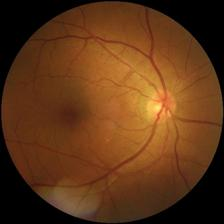

In [81]:
tf.keras.utils.array_to_img(original_imgs[0][0])

In [82]:
def GenHeatmap(model, base_model, last_layer: str, isEyeseeNet: bool, img_sample):
  base_grad_model = tf.keras.models.Model(
      inputs=base_model.input,
      outputs=[base_model.get_layer(last_layer).output, base_model.output]
  )

  if not isEyeseeNet:
    idx = model.layers.index(base_model)          # trova la posizione del sotto-modello
    layer_prima = model.layers[1:idx]              # layer PRIMA del sotto-modello (es. il preprocessing Lambda)
    layer_dopo = model.layers[idx + 1:]             # layer DOPO (GAP, Dense, Dropout, Dense)

    with tf.GradientTape() as tape:
        x = img_sample
        for layer in layer_prima:
            x = layer(x)                            # applica il preprocessing manualmente

        last_layer_activations, x = base_grad_model(x)  # passa dentro il sotto-modello

        for layer in layer_dopo:
            x = layer(x)                            # continua con GAP, Dense, ecc.

        preds = x
        class_index = tf.argmax(preds[0])
        class_score = preds[:, class_index]
  else:
    with tf.GradientTape() as tape:
      last_layer_activations, preds = base_grad_model(img_sample)
      class_index = tf.argmax(preds[0])             # ottiene l'indice della classe con probabilità più alta
      class_score = preds[:, class_index]           # e ricava gli score relativi a quella classe

  gradients = tape.gradient(class_score, last_layer_activations)

  W_channels = tf.reduce_mean(gradients, axis=(0, 1, 2))      # "appiattisce" l'informazione delle altre dimensioni facendo una media, lasciando invariata solo quella dei canali, trasformandola
                                                              # in una matrice di pesi a tutti gli effetti

  heatmap = last_layer_activations[0] @ W_channels[..., tf.newaxis]        # crea l'heatmap facendo il prodotto matriciale tra la matrice delle attivazioni e i pesi dei canali (tf.newaxis per permettere l'operazione)
  heatmap = tf.squeeze(heatmap)                                # squeeze rimuove le dimensioni pari a 1, quindi la dimensione temporanea aggiunta per la moltiplicazione precedente

  heatmap = tf.maximum(heatmap, 0)                                   # applica una ReLU per mantenere solo i pixel con impatto positivo sulla classe target, scartando quelli con impatto negativo
                                                                     # (che indicherebbero regioni "contro" la classe target e non a favore)

  heatmap = heatmap / tf.reduce_max(heatmap)       # compie una normalizzazione min-max per portare i valori dell'heatmap dentro l'intervallo [0, 1], così da poter costruire la colormap in seguito

  return heatmap

In [83]:
def OverlayColormap(img_sample, heatmap):
  jet = matplotlib.colormaps["jet"]
  jet_colors = jet(np.arange(256))[:, :3]     # scarta canale alpha/trasparenza
  heatmap_int = np.uint8(255 * heatmap)       # cambia il range da [0, 1] a [0, 255] per eseguire mappatura sulla scala di colori
  heatmap_colored = jet_colors[heatmap_int]

  heatmap_img = tf.keras.utils.array_to_img(heatmap_colored)
  heatmap_img = heatmap_img.resize((224,224))

  heatmap_array = tf.keras.utils.img_to_array(heatmap_img)

  alpha = 0.4
  overlayed = heatmap_array * 0.4 + img_sample
  return tf.keras.utils.array_to_img(overlayed)

In [84]:
overlayed_mobileNet = []
overlayed_efficientNet = []
overlayed_resNet = []
overlayed_eyeseeNet = []

for i in range(4):
  overlayed_mobileNet.append(OverlayColormap(original_imgs[i][0], GenHeatmap(mobileNet, mobileNet.get_layer("mobilenetv2_1.00_224"), "out_relu", False, original_imgs[i])))
  overlayed_efficientNet.append(OverlayColormap(original_imgs[i][0], GenHeatmap(efficientNet, efficientNet.get_layer("efficientnetb0"), "top_activation", False, original_imgs[i])))
  overlayed_resNet.append(OverlayColormap(original_imgs[i][0], GenHeatmap(resNet, resNet.get_layer("resnet50v2"), "post_relu", False, original_imgs[i])))
  overlayed_eyeseeNet.append(OverlayColormap(original_imgs[i][0], GenHeatmap(eyeseeNet, eyeseeNet, "conv2d_29", True, original_imgs[i])))


In [85]:
for i, array in enumerate(original_imgs):
  original_imgs[i] = tf.keras.utils.array_to_img(array[0])

all_images = [original_imgs, overlayed_mobileNet, overlayed_efficientNet, overlayed_resNet, overlayed_eyeseeNet]

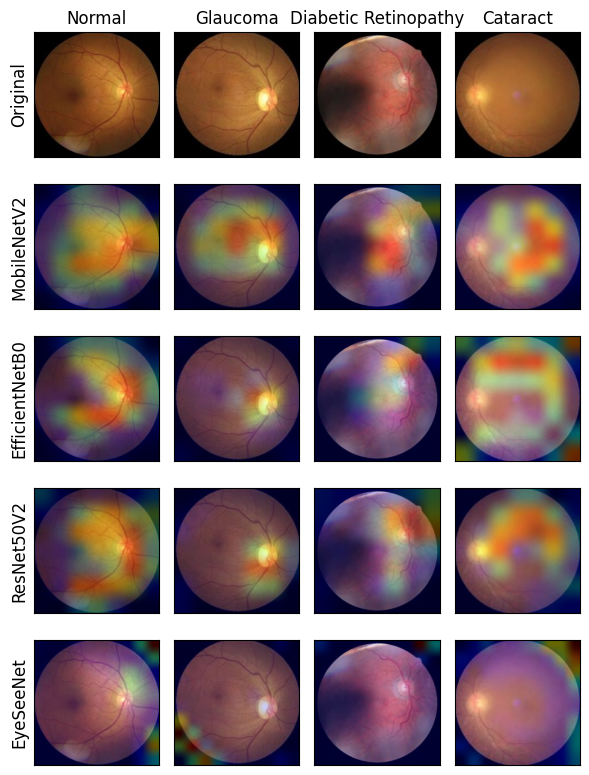

In [86]:
fig, axes = plt.subplots(5, 4, figsize=(6, 8))

row_labels = ['Original', 'MobileNetV2', 'EfficientNetB0', 'ResNet50V2', 'EyeSeeNet']
col_labels = ['Normal', 'Glaucoma', 'Diabetic Retinopathy', 'Cataract']

for i in range(5):
  for j in range(4):
    img = all_images[i][j]
    axes[i][j].imshow(img)
    axes[i][j].set_xticks([])
    axes[i][j].set_yticks([])

    if i == 0:
      axes[i][j].set_title(col_labels[j], fontsize = 12)

    if j == 0:
      axes[i][j].set_ylabel(row_labels[i], fontsize=12)

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/results/GradCAM_results.png")
plt.show()